In [1]:
from util.text_util import join_texts
%load_ext autoreload
%autoreload 2

# Load the BPMN Dataset

In [2]:
import os
from mcp4cm.bpmn.dataloading.dataloading import BPMNModelCollection
from mcp4cm.bpmn.dataloading.bpmn_dataset import BPMNDataset
from mcp4cm.dataloading import load_dataset
from mcp4cm.base import DatasetType

Defining file path for saving dataset and loading it later on.

In [3]:
bpmn_dataset = load_dataset(path='data/bpmnmodelset', dataset_type=DatasetType.BPMNMODELSET, bpmn_model_collection=BPMNModelCollection.BPMAI)

In [4]:
from mcp4cm.bpmn.data_extraction import extract_names_from_models
from mcp4cm.bpmn.constants import NAMES_WITH_TYPES_COLUMN, NAMES_COLUMN, EMPTY_NAME_TOKEN, BASE_BPMN_DATASETS_PATH

use_types = True
empty_name = EMPTY_NAME_TOKEN
checkpoint_folder = 'processed/bpmai'

if use_types:
    key = NAMES_WITH_TYPES_COLUMN
    checkpoint_path = os.path.join(BASE_BPMN_DATASETS_PATH, checkpoint_folder, 'typed_names.csv')
else:
    key = NAMES_COLUMN
    checkpoint_path = os.path.join(BASE_BPMN_DATASETS_PATH, checkpoint_folder, 'names_only.csv')


extract_names_from_models(bpmn_dataset, use_types=use_types, include_texts=True, include_documentation=True)


In [5]:
BPMNDataset.to_csv(bpmn_dataset, fp=checkpoint_path)

In [6]:
from mcp4cm.bpmn.dataloading.dataloading import load_processed_dataset_from_csv

del bpmn_dataset

bpmn_dataset = load_processed_dataset_from_csv("BPMAI", checkpoint_path)


In [7]:

from bpmn.filter_functions import filter_empty_models, filter_models_by_min_element_count, \
    filter_models_by_max_element_count, filter_models_by_element_count, filter_models_by_empty_name_percentage, \
    filter_models_by_dummy_words, filter_models_by_median_name_length, filter_models_by_required_elements, \
    filter_models_by_duplicate_activities
from mcp4cm.dataloading import Dataset

print(bpmn_dataset)
Dataset.apply_filters(
    dataset=bpmn_dataset,
    filters=[
        filter_empty_models,
        filter_models_by_empty_name_percentage,
        filter_models_by_min_element_count,
        filter_models_by_required_elements,
        filter_models_by_dummy_words,
        filter_models_by_median_name_length,
        filter_models_by_duplicate_activities
    ],
)

print(bpmn_dataset)

Dataset(name=BPMAI, models=18812)
Filtered out models where every element is unnamed: 737
Filtered out models with a empty name percentage higher than 0.35: 3
Filtered out models with element counts smaller than 5: 186
Filtered out models which do not have minimally required elements: 2626
Filtered out models with a dummy_percentage higher than 0.6: 4
Filtered out models with a median name length smaller than 3: 7051
Filtered out models with duplicate activity names higher than 0.4: 313
Dataset(name=BPMAI, models=7892)


In [8]:
from mcp4cm.language_detection import extract_dataset_languages, get_models_by_language

extract_dataset_languages(bpmn_dataset, text_key=key, empty_name=empty_name, override=False)


Language Extraction Progress: 0it [00:00, ?it/s]

In [9]:
from mcp4cm.language_detection import filter_models_by_language
english_dataset = filter_models_by_language(bpmn_dataset, 'en', key=key, empty_name=empty_name)

print(f"Filtered Dataset to {len(english_dataset)} English models.")

del bpmn_dataset

Filtered Dataset to 3751 English models.


In [10]:
checkpoint_path = os.path.join(BASE_BPMN_DATASETS_PATH, checkpoint_folder, 'english_typed_names.csv')
BPMNDataset.to_csv(english_dataset, checkpoint_path);
print(f"Saved {len(english_dataset)} models in dataset {english_dataset.name} to csv file")


Saved 3751 models in dataset BPMAI to csv file



=== Dataset Statistics ===
Hash calculation and duplicate detection took 0.08 seconds.
Total number of models: 3751
Total unique files: 3336
Total duplicate files: 415
Number of duplicate groups: 190
Keeping 3336 unique models and 190 representatives of duplicate groups = 3526 models


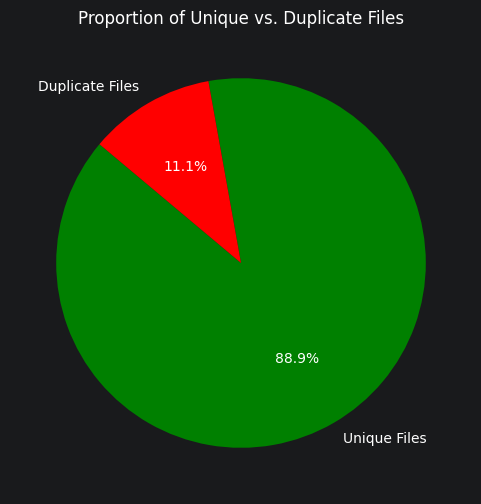

In [11]:
from mcp4cm.duplicate_detection import detect_duplicates_by_hash
hash_unique, hash_duplicate = detect_duplicates_by_hash(english_dataset, key=key, inplace=True, plt_fig=True, print_results=True, keep_one=True)


creating tfidf for names_with_types
Generating Connectivity Graph
Connectivity Graph Done
Calculating connected Components
Calculating connected Components Done
Number of components: 3039
Finding unique files:
Creating Duplicate Groups

=== Dataset Statistics ===
Total files processed: 3526
Total unique files: 2785
Total duplicate files: 741
Number of duplicate groups: 254
Keeping 2785 unique models and 254 representatives of duplicate groups = 3039 models


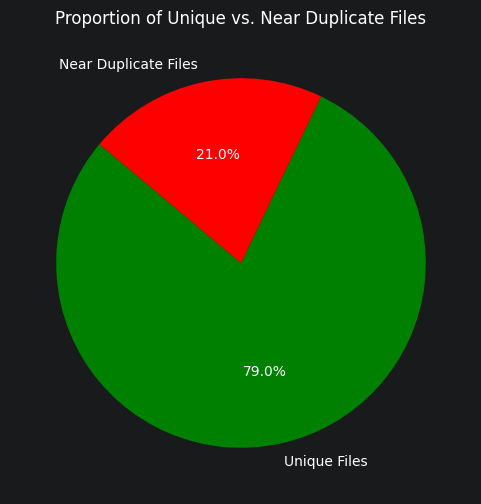

Verify: Length of keep index 254 == Duplicate Groups: 254


In [12]:
from mcp4cm.duplicate_detection import tfidf_near_duplicate_detector
unique_dataset, duplicate_dataset = tfidf_near_duplicate_detector(english_dataset,key=key, threshold=0.95, inplace=True, plt_fig=True, print_results=True, keep_one=True)

In [15]:
filtered_checkpoint_path = os.path.join(BASE_BPMN_DATASETS_PATH, checkpoint_folder, 'english_filtered_deduplicated_typed.csv')
BPMNDataset.to_csv(english_dataset, filtered_checkpoint_path)

BPMNDataset.to_files(english_dataset, output_directory='data/export/bpmai_typed_clean', include_svg=True)

KeyboardInterrupt: 